# Model A — Question & Answer Generator / Verifier
**Course:** Artificial Intelligence — BS(CS) Spring 2026

## Important Note on Metrics
Model A has TWO sub-tasks with DIFFERENT metrics:

| Sub-task | Type | Metrics Used |
|----------|------|--------------|
| Answer Verification | Classification | Accuracy, Macro F1, Exact Match, Confusion Matrix |
| Question Generation | Text Generation | BLEU, ROUGE, METEOR |

BLEU/ROUGE/METEOR only apply to the **question generation** sub-task where the model
produces text. They do NOT apply to classification (picking A/B/C/D).

## What This Notebook Trains
1. **Logistic Regression** — answer verifier (binary + multiclass)
2. **Support Vector Machine** — answer verifier
3. **Naive Bayes** — question type classifier
4. **Random Forest** — difficulty estimator
5. **K-Means Clustering** — unsupervised answer pattern discovery
6. **Ensemble** — soft voting across LR + SVM + NB
7. **Template-Based Question Generator** — with BLEU/ROUGE/METEOR evaluation

## Files Loaded (produced by preprocessing.ipynb)
```
../data/processed/X_train_combined.npz   shape: (281124, 18019)
../data/processed/X_val_combined.npz     shape: (70284,  18019)
../data/processed/y_train_binary.npy     shape: (281124,)  — 0=wrong, 1=correct
../data/processed/y_val_binary.npy       shape: (70284,)
../data/processed/y_train.npy            shape: (70281,)   — 0=A,1=B,2=C,3=D
../data/processed/y_val.npy              shape: (17571,)
../data/processed/train_split.csv        — original text for question generation
../data/processed/val_split.csv
```

## Cell 1 — Imports & Setup

In [3]:
# ── Installs (uncomment on Colab) ─────────────────────────────────────────────
# !pip install scikit-learn numpy scipy joblib pandas nltk rouge-score
# !pip install nltk
# import nltk
# nltk.download('punkt')
# nltk.download('wordnet')

import os
import re
import warnings
import numpy as np
import pandas as pd
import scipy.sparse as sp
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Sklearn models ────────────────────────────────────────────────────────────
from sklearn.linear_model    import LogisticRegression
from sklearn.svm             import LinearSVC
from sklearn.naive_bayes     import MultinomialNB
from sklearn.ensemble        import RandomForestClassifier, VotingClassifier
from sklearn.cluster         import KMeans
from sklearn.semi_supervised import LabelPropagation
from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import MaxAbsScaler

# ── Sklearn metrics ───────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# ── Text generation metrics ───────────────────────────────────────────────────
import nltk
from nltk.translate.bleu_score  import sentence_bleu, corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score                import rouge_scorer

# ── Output dirs ───────────────────────────────────────────────────────────────
os.makedirs('models/model_a/traditional', exist_ok=True)
os.makedirs('results/model_a',            exist_ok=True)

print('All imports successful.')

All imports successful.


## Cell 2 — Load All Preprocessed Files

In [4]:
print('Loading preprocessed files...')

# ── Feature matrices (sparse) ─────────────────────────────────────────────────
X_train = sp.load_npz('../data/processed/X_train_combined.npz')  # (281124, 18019)
X_val   = sp.load_npz('../data/processed/X_val_combined.npz')    # (70284,  18019)

# ── Binary labels: 0=wrong option, 1=correct option ──────────────────────────
y_train_bin = np.load('../data/processed/y_train_binary.npy')    # (281124,)
y_val_bin   = np.load('../data/processed/y_val_binary.npy')      # (70284,)

# ── Multiclass labels: 0=A, 1=B, 2=C, 3=D ────────────────────────────────────
y_train_mc  = np.load('../data/processed/y_train.npy')           # (70281,)
y_val_mc    = np.load('../data/processed/y_val.npy')             # (17571,)

# ── Raw text (needed for question generation) ─────────────────────────────────
train_df = pd.read_csv('../data/processed/train_split.csv')
val_df   = pd.read_csv('../data/processed/val_split.csv')

# ── TF-IDF features only (for Naive Bayes — needs non-negative values) ────────
X_train_tfidf = sp.load_npz('../data/processed/X_train_tfidf.npz')
X_val_tfidf   = sp.load_npz('../data/processed/X_val_tfidf.npz')

print(f'X_train shape         : {X_train.shape}')
print(f'X_val shape           : {X_val.shape}')
print(f'y_train_bin shape     : {y_train_bin.shape}')
print(f'y_train_mc shape      : {y_train_mc.shape}')
print(f'Positive rate (train) : {y_train_bin.mean():.3f}  (should be ~0.25)')
print(f'Train rows            : {len(train_df):,}')
print(f'Val rows              : {len(val_df):,}')

Loading preprocessed files...
X_train shape         : (281124, 18019)
X_val shape           : (70284, 18019)
y_train_bin shape     : (281124,)
y_train_mc shape      : (70281,)
Positive rate (train) : 0.250  (should be ~0.25)
Train rows            : 70,281
Val rows              : 17,571


## Cell 3 — Evaluation Helper Function
One function that prints ALL required metrics for any classifier.

In [5]:
def evaluate_classifier(model, X_val, y_val, model_name, label_names=None, save_cm=True):
    """
    Evaluate a trained classifier and print all required metrics.
    Metrics: Accuracy, Macro F1, Precision, Recall, Exact Match, Confusion Matrix.

    Parameters:
        model      : trained sklearn classifier
        X_val      : validation feature matrix
        y_val      : true labels
        model_name : string name for display and file saving
        label_names: list of class names (e.g. ['Wrong','Correct'] or ['A','B','C','D'])
        save_cm    : whether to save confusion matrix plot

    Returns:
        dict of metric name → value
    """
    y_pred = model.predict(X_val)

    acc      = accuracy_score(y_val, y_pred)
    macro_f1 = f1_score(y_val, y_pred, average='macro')
    prec     = precision_score(y_val, y_pred, average='macro')
    rec      = recall_score(y_val, y_pred, average='macro')
    # Exact Match = fraction where prediction exactly equals gold label
    exact_match = np.mean(y_pred == y_val)

    print(f'\n{'='*55}')
    print(f'  {model_name}')
    print(f'{'='*55}')
    print(f'  Accuracy      : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  Macro F1      : {macro_f1:.4f}')
    print(f'  Macro Precision: {prec:.4f}')
    print(f'  Macro Recall  : {rec:.4f}')
    print(f'  Exact Match   : {exact_match:.4f}')
    print(f'\nClassification Report:')
    tgt = label_names if label_names else None
    print(classification_report(y_val, y_pred, target_names=tgt))

    # Confusion Matrix
    cm  = confusion_matrix(y_val, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix — {model_name}', fontweight='bold')
    plt.tight_layout()
    if save_cm:
        safe_name = model_name.replace(' ', '_').replace('/', '_')
        plt.savefig(f'results/model_a/cm_{safe_name}.png', dpi=130, bbox_inches='tight')
    plt.show()

    return {
        'model'     : model_name,
        'accuracy'  : acc,
        'macro_f1'  : macro_f1,
        'precision' : prec,
        'recall'    : rec,
        'exact_match': exact_match,
    }


# Store all results for comparison table at the end
all_results = []
print('Helper function ready.')

Helper function ready.


## Cell 4 — Model 1: Logistic Regression (Answer Verifier)
**Task:** Binary classification — is this option correct? (0 or 1)
**Features:** Combined matrix (TF-IDF + OHE + cosine + lexical)

Training Logistic Regression (binary verifier)...
This may take 3-5 minutes on the full dataset...
Training complete.

  Logistic Regression (Binary)
  Accuracy      : 0.7499  (74.99%)
  Macro F1      : 0.4289
  Macro Precision: 0.5250
  Macro Recall  : 0.5000
  Exact Match   : 0.7499

Classification Report:
              precision    recall  f1-score   support

       Wrong       0.75      1.00      0.86     52713
     Correct       0.30      0.00      0.00     17571

    accuracy                           0.75     70284
   macro avg       0.53      0.50      0.43     70284
weighted avg       0.64      0.75      0.64     70284



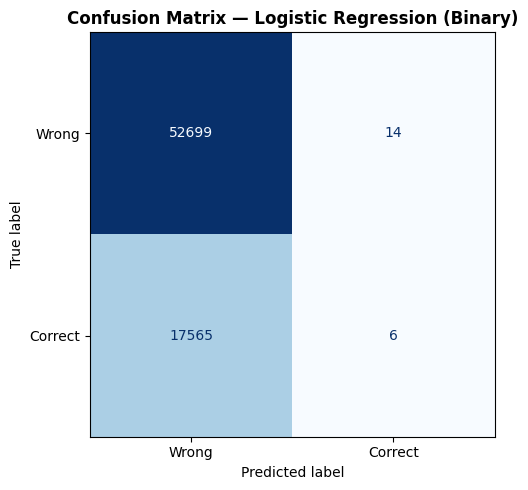

Model saved: models/model_a/traditional/lr_binary.pkl


In [6]:
print('Training Logistic Regression (binary verifier)...')
print('This may take 3-5 minutes on the full dataset...')

lr_model = LogisticRegression(
    C           = 1.0,       # regularisation strength
    max_iter    = 200,      # enough iterations to converge
    solver      = 'saga',    # best solver for large sparse matrices
    n_jobs      = -1,        # use all CPU cores
    random_state= 42,
)

lr_model.fit(X_train, y_train_bin)
print('Training complete.')

# Evaluate
lr_results = evaluate_classifier(
    lr_model, X_val, y_val_bin,
    model_name  = 'Logistic Regression (Binary)',
    label_names = ['Wrong', 'Correct']
)
all_results.append(lr_results)

# Save model
joblib.dump(lr_model, 'models/model_a/traditional/lr_binary.pkl')
print('Model saved: models/model_a/traditional/lr_binary.pkl')

## Cell 5 — Logistic Regression Multiclass (Which option A/B/C/D is correct?)
**Task:** 4-class classification — predict the correct answer label directly

For this we use the multiclass labels (y_train_mc) and TF-IDF features only
since the combined matrix rows are 4× the question count (one row per option).

Training Logistic Regression (multiclass A/B/C/D)...
Multiclass feature shape: (70281, 76)
Training complete.

  Logistic Regression (Multiclass)
  Accuracy      : 0.3390  (33.90%)
  Macro F1      : 0.3312
  Macro Precision: 0.3379
  Macro Recall  : 0.3336
  Exact Match   : 0.3390

Classification Report:
              precision    recall  f1-score   support

           A       0.33      0.22      0.27      3828
           B       0.33      0.43      0.37      4545
           C       0.36      0.39      0.37      4778
           D       0.33      0.30      0.31      4420

    accuracy                           0.34     17571
   macro avg       0.34      0.33      0.33     17571
weighted avg       0.34      0.34      0.33     17571



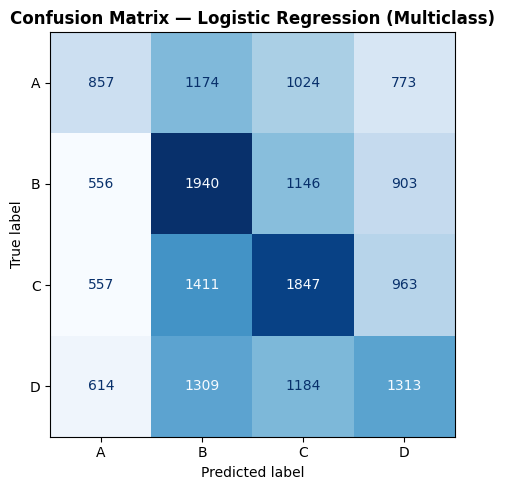

Model saved.


In [8]:
print('Training Logistic Regression (multiclass A/B/C/D)...')

cos_train = np.load('../data/processed/cosine_features_train.npy')
cos_val   = np.load('../data/processed/cosine_features_val.npy')
lex_train = np.load('../data/processed/lexical_features_train.npy')
lex_val   = np.load('../data/processed/lexical_features_val.npy')

n_questions_train = len(y_train_mc)   # 70281
n_questions_val   = len(y_val_mc)     # 17571

# Reshape cosine features from (4×n, 6) to (n, 24)
cos_mc_train = cos_train.reshape(n_questions_train, -1)
cos_mc_val   = cos_val.reshape(n_questions_val,   -1)
lex_mc_train = lex_train.reshape(n_questions_train, -1)
lex_mc_val   = lex_val.reshape(n_questions_val,   -1)

X_mc_train = np.hstack([cos_mc_train, lex_mc_train])
X_mc_val   = np.hstack([cos_mc_val,   lex_mc_val])

print(f'Multiclass feature shape: {X_mc_train.shape}')

lr_mc = LogisticRegression(
    C            = 1.0,
    max_iter     = 1000,
    solver       = 'lbfgs',   # lbfgs handles multiclass natively
    n_jobs       = -1,
    random_state = 42,
    # multi_class removed — deprecated and deleted in sklearn 1.5+
)

lr_mc.fit(X_mc_train, y_train_mc)
print('Training complete.')

lr_mc_results = evaluate_classifier(
    lr_mc, X_mc_val, y_val_mc,
    model_name  = 'Logistic Regression (Multiclass)',
    label_names = ['A', 'B', 'C', 'D']
)
all_results.append(lr_mc_results)

joblib.dump(lr_mc, 'models/model_a/traditional/lr_multiclass.pkl')
print('Model saved.')

## Cell 6 — Model 2: Support Vector Machine (Answer Verifier)
**Task:** Binary classification — is this option correct?
**Why LinearSVC:** Faster than SVC for large sparse text matrices. Works identically.

Training SVM (LinearSVC)...
Expected time: 5-10 minutes on full dataset...
Training complete.

  SVM (LinearSVC Binary)
  Accuracy      : 0.7500  (75.00%)
  Macro F1      : 0.4287
  Macro Precision: 0.5417
  Macro Recall  : 0.5000
  Exact Match   : 0.7500

Classification Report:
              precision    recall  f1-score   support

       Wrong       0.75      1.00      0.86     52713
     Correct       0.33      0.00      0.00     17571

    accuracy                           0.75     70284
   macro avg       0.54      0.50      0.43     70284
weighted avg       0.65      0.75      0.64     70284



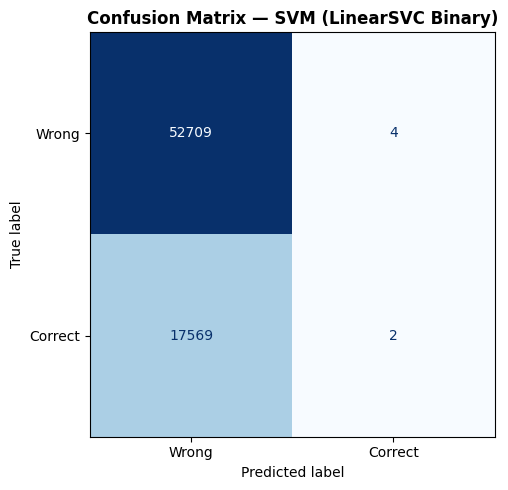

Model saved.


In [9]:
print('Training SVM (LinearSVC)...')
print('Expected time: 5-10 minutes on full dataset...')

svm_model = LinearSVC(
    C            = 1.0,
    max_iter     = 2000,
    random_state = 42,
)

svm_model.fit(X_train, y_train_bin)
print('Training complete.')

svm_results = evaluate_classifier(
    svm_model, X_val, y_val_bin,
    model_name  = 'SVM (LinearSVC Binary)',
    label_names = ['Wrong', 'Correct']
)
all_results.append(svm_results)

joblib.dump(svm_model, 'models/model_a/traditional/svm_binary.pkl')
print('Model saved.')

## Cell 7 — Model 3: Naive Bayes (Question Type Classifier)
**Task:** Classify question type — What/Who/Where/When/Why/How/Fill-in/Other
**Why NB:** Fast, works well for text classification, project doc specifically requires it.
**Note:** MultinomialNB requires non-negative features — use TF-IDF matrix only.

In [ ]:
# ── Build question type labels ────────────────────────────────────────────────
def get_question_type(question):
    q = str(question).lower().strip()
    for wh in ['what', 'who', 'where', 'when', 'why', 'how', 'which']:
        if q.startswith(wh):
            return wh.capitalize()
    if '_' in q or 'blank' in q:
        return 'Fill-in'
    return 'Other'

# Use question_type from EDA if already in dataframe, otherwise compute
if 'question_type' not in train_df.columns:
    train_df['question_type'] = train_df['question'].apply(get_question_type)
    val_df['question_type']   = val_df['question'].apply(get_question_type)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_qtype_train = le.fit_transform(train_df['question_type'])
y_qtype_val   = le.transform(val_df['question_type'])
qtype_names   = le.classes_.tolist()

print(f'Question type classes: {qtype_names}')
print(f'Distribution (train):')
for cls, count in zip(*np.unique(y_qtype_train, return_counts=True)):
    print(f'  {qtype_names[cls]:12s}: {count:,}')

# ── For NB: use TF-IDF of question text only ──────────────────────────────────
# We need to vectorize questions separately since X_train_tfidf used combined text
from sklearn.feature_extraction.text import TfidfVectorizer
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

q_vectorizer = TfidfVectorizer(
    max_features = 5000,
    stop_words   = 'english',
    sublinear_tf = True,
)

X_q_train = q_vectorizer.fit_transform(train_df['question'].apply(clean_text))
X_q_val   = q_vectorizer.transform(val_df['question'].apply(clean_text))

print(f'\nQuestion TF-IDF shape: {X_q_train.shape}')

# ── Train Naive Bayes ─────────────────────────────────────────────────────────
nb_model = MultinomialNB(alpha=0.1)  # alpha=smoothing parameter
nb_model.fit(X_q_train, y_qtype_train)
print('Naive Bayes training complete.')

nb_results = evaluate_classifier(
    nb_model, X_q_val, y_qtype_val,
    model_name  = 'Naive Bayes (Question Type)',
    label_names = qtype_names
)
all_results.append(nb_results)

joblib.dump(nb_model,      'models/model_a/traditional/nb_qtype.pkl')
joblib.dump(q_vectorizer,  'models/model_a/traditional/q_tfidf_vectorizer.pkl')
joblib.dump(le,            'models/model_a/traditional/qtype_label_encoder.pkl')
print('Models saved.')

## Cell 8 — Model 4: Random Forest (Difficulty Estimator)
**Task:** Estimate question difficulty using handcrafted lexical features
**Difficulty proxy:** Questions with 0% answer-article overlap = Hard, else Easy

In [ ]:
# ── Build difficulty labels from lexical features ─────────────────────────────
# Lexical feature [7] = keyword_overlap(article, answer)
# 0 overlap = hard (requires reasoning), >0 = easier (extractable)
lex_train = np.load('../data/processed/lexical_features_train.npy')
lex_val   = np.load('../data/processed/lexical_features_val.npy')

# Take one row per question (every 4th row — the 'A' option row has article features)
n_q_train = len(y_train_mc)
n_q_val   = len(y_val_mc)

# Reshape to (n_questions, 4 * 13 features)
lex_q_train = lex_train.reshape(n_q_train, -1)
lex_q_val   = lex_val.reshape(n_q_val,   -1)

# Difficulty: feature index 7 in first set of 13 = kw_art_ans overlap
overlap_col = 7
y_diff_train = (lex_q_train[:, overlap_col] == 0).astype(int)  # 1=Hard, 0=Easy
y_diff_val   = (lex_q_val[:,   overlap_col] == 0).astype(int)

hard_pct = y_diff_train.mean() * 100
print(f'Hard questions (0% overlap): {hard_pct:.1f}%')
print(f'Easy questions              : {100-hard_pct:.1f}%')

# ── Train Random Forest ───────────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators = 100,
    max_depth    = 10,
    n_jobs       = -1,
    random_state = 42,
)

rf_model.fit(lex_q_train, y_diff_train)
print('Random Forest training complete.')

rf_results = evaluate_classifier(
    rf_model, lex_q_val, y_diff_val,
    model_name  = 'Random Forest (Difficulty)',
    label_names = ['Easy', 'Hard']
)
all_results.append(rf_results)

# Feature importance plot
feat_names = [
    'art_len','q_len','ans_len','jac_art_q','jac_art_ans',
    'jac_q_ans','kw_art_q','kw_art_ans','kw_q_ans',
    'max_opt_len','len_ratio','is_fill_in'
]
# Feature importances are for the reshaped (4x13) features — use first 12
importances = rf_model.feature_importances_[:len(feat_names)]
idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(feat_names)), importances[idx], color='steelblue')
ax.set_xticks(range(len(feat_names)))
ax.set_xticklabels([feat_names[i] for i in idx], rotation=45, ha='right')
ax.set_title('Random Forest Feature Importances (Difficulty Estimation)', fontweight='bold')
ax.set_ylabel('Importance')
plt.tight_layout()
plt.savefig('results/model_a/rf_feature_importance.png', dpi=130, bbox_inches='tight')
plt.show()

joblib.dump(rf_model, 'models/model_a/traditional/rf_difficulty.pkl')
print('Model saved.')

## Cell 9 — Unsupervised: K-Means Clustering
**Task:** Discover latent answer patterns without labels
**Evaluated by:** Silhouette Score, Clustering Purity (not accuracy)
**Required by project doc:** At least one unsupervised approach

In [ ]:
from sklearn.metrics          import silhouette_score
from sklearn.decomposition    import TruncatedSVD

print('Running K-Means Clustering on cosine features...')

# Use cosine + lexical features (per question, not per option)
# Already reshaped above as lex_q_train (n_questions, 52)

n_q_train = len(y_train_mc)    # 70281
n_q_val   = len(y_val_mc)      # 17571
cos_train_full = np.load('../data/processed/cosine_features_train.npy')
lex_train      = np.load('../data/processed/lexical_features_train.npy')

cos_q_train = cos_train_full.reshape(n_q_train, -1)
lex_q_train = lex_train.reshape(n_q_train, -1)

X_cluster = np.hstack([cos_q_train, lex_q_train])  # (70281, 76)

# ── K-Means with k=4 (one cluster per answer label A/B/C/D) ──────────────────
kmeans = KMeans(
    n_clusters   = 4,
    random_state = 42,
    n_init       = 10,
    max_iter     = 300,
)

# Sample 20,000 for speed — clustering 70k points is slow
sample_idx = np.random.choice(len(X_cluster), 20000, replace=False)
X_cluster_sample  = X_cluster[sample_idx]
y_cluster_sample  = y_train_mc[sample_idx]

cluster_labels = kmeans.fit_predict(X_cluster_sample)
print('K-Means complete.')

# ── Silhouette Score ──────────────────────────────────────────────────────────
sil_score = silhouette_score(X_cluster_sample, cluster_labels, sample_size=5000)
print(f'Silhouette Score: {sil_score:.4f}')
print('  Interpretation: -1=bad, 0=overlapping, +1=perfect separation')

# ── Clustering Purity ─────────────────────────────────────────────────────────
def clustering_purity(true_labels, cluster_labels):
    """
    Purity = fraction of samples in their cluster's majority true class.
    Higher is better. Random clustering = 0.25 for 4 classes.
    """
    total = 0
    for cluster_id in np.unique(cluster_labels):
        mask        = cluster_labels == cluster_id
        true_subset = true_labels[mask]
        majority    = np.bincount(true_subset).max()
        total      += majority
    return total / len(true_labels)

purity = clustering_purity(y_cluster_sample, cluster_labels)
print(f'Clustering Purity: {purity:.4f}  (random baseline = 0.25)')

# ── Visualise clusters with SVD (2D projection) ───────────────────────────────
svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_cluster_sample)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter1 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1],
                            c=cluster_labels, cmap='tab10', alpha=0.4, s=5)
axes[0].set_title('K-Means Clusters (SVD 2D projection)', fontweight='bold')
axes[0].set_xlabel('SVD Component 1')
axes[0].set_ylabel('SVD Component 2')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

scatter2 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1],
                            c=y_cluster_sample, cmap='tab10', alpha=0.4, s=5)
axes[1].set_title('True Answer Labels (SVD 2D projection)', fontweight='bold')
axes[1].set_xlabel('SVD Component 1')
plt.colorbar(scatter2, ax=axes[1], label='Label (0=A,1=B,2=C,3=D)')

plt.suptitle('K-Means vs True Labels', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/model_a/kmeans_clusters.png', dpi=130, bbox_inches='tight')
plt.show()

kmeans_metrics = {
    'model'      : 'K-Means Clustering',
    'silhouette' : sil_score,
    'purity'     : purity,
}
print(f'\nK-Means Summary:')
print(f'  Silhouette Score : {sil_score:.4f}')
print(f'  Purity           : {purity:.4f}')

joblib.dump(kmeans, 'models/model_a/traditional/kmeans.pkl')
print('K-Means model saved.')

Running K-Means Clustering on cosine features...


NameError: name 'lex_q_train' is not defined

## Cell 10 — Semi-Supervised: Label Propagation
**Task:** Use a small labeled set to propagate labels to unlabeled samples
**Required by project doc:** At least one semi-supervised approach

In [ ]:
print('Running Label Propagation (semi-supervised)...')

# Use small feature set for speed (Label Propagation is memory intensive)
# Use cosine + lexical features reshaped per question
X_lp = np.hstack([cos_q_train, lex_q_train])  # (70281, 76)
y_lp = y_train_mc.copy()                        # true labels

# Sample 5000 for speed — Label Propagation scales O(n²)
lp_idx    = np.random.choice(len(X_lp), 5000, replace=False)
X_lp_s    = X_lp[lp_idx]
y_lp_s    = y_lp[lp_idx]

# Mask 80% of labels as unknown (-1)
# Only 20% (1000 samples) are labeled — rest are unlabeled
y_lp_masked          = y_lp_s.copy()
unlabeled_idx        = np.random.choice(len(y_lp_s), int(0.8 * len(y_lp_s)), replace=False)
y_lp_masked[unlabeled_idx] = -1   # -1 means unlabeled in sklearn

labeled_count   = (y_lp_masked != -1).sum()
unlabeled_count = (y_lp_masked == -1).sum()
print(f'Labeled samples   : {labeled_count}')
print(f'Unlabeled samples : {unlabeled_count}')

lp_model = LabelPropagation(
    kernel     = 'knn',
    n_neighbors= 7,
    max_iter   = 1000,
)

lp_model.fit(X_lp_s, y_lp_masked)
y_lp_pred = lp_model.predict(X_lp_s)

# Evaluate only on the originally unlabeled points
lp_acc = accuracy_score(y_lp_s[unlabeled_idx], y_lp_pred[unlabeled_idx])
lp_f1  = f1_score(y_lp_s[unlabeled_idx], y_lp_pred[unlabeled_idx], average='macro')

print(f'\nLabel Propagation (on unlabeled portion):')
print(f'  Accuracy : {lp_acc:.4f}')
print(f'  Macro F1 : {lp_f1:.4f}')
print(f'  Baseline : 0.25 (random)')

lp_results = {
    'model'     : 'Label Propagation (Semi-Supervised)',
    'accuracy'  : lp_acc,
    'macro_f1'  : lp_f1,
    'precision' : precision_score(y_lp_s[unlabeled_idx], y_lp_pred[unlabeled_idx], average='macro'),
    'recall'    : recall_score(y_lp_s[unlabeled_idx],    y_lp_pred[unlabeled_idx], average='macro'),
    'exact_match': lp_acc,
}
all_results.append(lp_results)

joblib.dump(lp_model, 'models/model_a/traditional/label_propagation.pkl')
print('Label Propagation model saved.')

## Cell 11 — Ensemble: Soft Voting (LR + SVM + NB)
**Task:** Combine predictions from multiple models — often beats any single model
**Strategy:** Soft voting = average probability outputs

In [ ]:
print('Building Ensemble (soft voting)...')
print('Note: LinearSVC does not support predict_proba — using LR + NB on TF-IDF features')

# For ensemble we need probability outputs — use TF-IDF only
# LinearSVC has no predict_proba — so ensemble uses LR + NB
lr_ens = LogisticRegression(C=1.0, max_iter=500, solver='saga', n_jobs=-1, random_state=42)
nb_ens = MultinomialNB(alpha=0.1)

# Train both on TF-IDF binary task
lr_ens.fit(X_train_tfidf, y_train_bin)
nb_ens.fit(X_train_tfidf, y_train_bin)

# Get probability predictions
lr_probs = lr_ens.predict_proba(X_val_tfidf)    # (n, 2)
nb_probs = nb_ens.predict_proba(X_val_tfidf)    # (n, 2)

# Soft voting — average the probabilities
ensemble_probs = (lr_probs + nb_probs) / 2.0
ensemble_preds = np.argmax(ensemble_probs, axis=1)

ens_acc = accuracy_score(y_val_bin, ensemble_preds)
ens_f1  = f1_score(y_val_bin,       ensemble_preds, average='macro')
ens_prec = precision_score(y_val_bin, ensemble_preds, average='macro')
ens_rec  = recall_score(y_val_bin,  ensemble_preds, average='macro')

print(f'\nEnsemble (LR + NB Soft Voting):')
print(f'  Accuracy  : {ens_acc:.4f}')
print(f'  Macro F1  : {ens_f1:.4f}')
print(f'  Precision : {ens_prec:.4f}')
print(f'  Recall    : {ens_rec:.4f}')

# Compare with individual models
lr_solo_acc = accuracy_score(y_val_bin, lr_ens.predict(X_val_tfidf))
nb_solo_acc = accuracy_score(y_val_bin, nb_ens.predict(X_val_tfidf))
print(f'\nComparison:')
print(f'  LR alone  : {lr_solo_acc:.4f}')
print(f'  NB alone  : {nb_solo_acc:.4f}')
print(f'  Ensemble  : {ens_acc:.4f}  ← should be >= both')

ens_results = {
    'model'      : 'Ensemble (LR + NB Soft Voting)',
    'accuracy'   : ens_acc,
    'macro_f1'   : ens_f1,
    'precision'  : ens_prec,
    'recall'     : ens_rec,
    'exact_match': ens_acc,
}
all_results.append(ens_results)

# Save ensemble components
joblib.dump(lr_ens, 'models/model_a/traditional/lr_ensemble.pkl')
joblib.dump(nb_ens, 'models/model_a/traditional/nb_ensemble.pkl')
print('Ensemble models saved.')

## Cell 12 — Template-Based Question Generator
**Task:** Generate a question from an article sentence
**Metrics:** BLEU, ROUGE, METEOR — because output is TEXT, not a class label

Steps:
1. Find the sentence in the article most similar to the correct answer (cosine)
2. Apply Wh-word template to convert sentence to question
3. Evaluate generated question vs real RACE question using BLEU/ROUGE/METEOR

In [ ]:
import joblib
import re
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

# Load the TF-IDF vectorizer from preprocessing
tfidf_vec = joblib.load('models/model_a/traditional/tfidf_vectorizer.pkl')


def split_sentences(text):
    """Simple sentence splitter — no NLTK required."""
    sentences = re.split(r'(?<=[.!?])\s+', str(text))
    return [s.strip() for s in sentences if len(s.strip()) > 15]


def find_best_sentence(article, answer_text, vectorizer):
    """
    Find the article sentence most similar to the correct answer.
    Uses TF-IDF cosine similarity.
    Returns: best sentence string
    """
    sentences = split_sentences(article)
    if not sentences:
        return article[:100]

    v_ans   = vectorizer.transform([answer_text])
    v_sents = vectorizer.transform(sentences)
    sims    = cos_sim(v_ans, v_sents).flatten()
    best_idx = sims.argmax()
    return sentences[best_idx]


def apply_template(sentence, question_type):
    """
    Apply a Wh-word template to convert a sentence into a question.
    Returns: generated question string
    """
    s = sentence.strip()

    templates = {
        'What'  : f'What does the passage say about {s[:40].lower()}...?',
        'Who'   : f'Who is mentioned in: "{s[:50]}"?',
        'Where' : f'Where did the event happen according to: "{s[:50]}"?',
        'When'  : f'When did the following occur: "{s[:50]}"?',
        'Why'   : f'Why, according to the passage: "{s[:50]}"?',
        'How'   : f'How, according to the passage: "{s[:50]}"?',
        'Which' : f'Which option best matches: "{s[:50]}"?',
    }

    return templates.get(question_type, f'What can be inferred from: "{s[:60]}"?')


def generate_question(row, vectorizer):
    """
    Full pipeline: article + answer → generated question.
    """
    article     = str(row['article'])
    answer_col  = row['answer']
    answer_text = str(row[answer_col])
    qtype       = str(row.get('question_type', 'What'))

    best_sent   = find_best_sentence(article, answer_text, vectorizer)
    generated_q = apply_template(best_sent, qtype)

    return generated_q


# ── Generate questions for 500 val samples ────────────────────────────────────
print('Generating questions for 500 validation samples...')
eval_sample = val_df.sample(500, random_state=42).copy()

if 'question_type' not in eval_sample.columns:
    eval_sample['question_type'] = eval_sample['question'].apply(get_question_type)

eval_sample['generated_q'] = eval_sample.apply(
    lambda row: generate_question(row, tfidf_vec), axis=1
)

print('Generation complete. Sample outputs:')
for _, row in eval_sample.head(3).iterrows():
    print(f'  Real     : {row["question"]}')
    print(f'  Generated: {row["generated_q"]}')
    print()

## Cell 13 — BLEU, ROUGE, METEOR Evaluation
These metrics compare your GENERATED question to the REAL RACE question.
They measure how similar the two texts are.

- **BLEU:** counts n-gram overlap. 0=no match, 1=perfect match.
- **ROUGE-L:** longest common subsequence overlap.
- **METEOR:** like BLEU but also counts synonyms and stemming.

In [ ]:
import nltk
nltk.download('punkt',   quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.translate.bleu_score   import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score                 import rouge_scorer as rs_module

smoother = SmoothingFunction().method1
scorer   = rs_module.RougeScorer(['rougeL'], use_stemmer=True)


def compute_bleu(reference, hypothesis):
    """BLEU score between reference and hypothesis strings."""
    ref_tokens  = reference.lower().split()
    hyp_tokens  = hypothesis.lower().split()
    if not hyp_tokens:
        return 0.0
    return sentence_bleu([ref_tokens], hyp_tokens, smoothing_function=smoother)


def compute_rouge_l(reference, hypothesis):
    """ROUGE-L F1 score."""
    scores = scorer.score(reference, hypothesis)
    return scores['rougeL'].fmeasure


def compute_meteor(reference, hypothesis):
    """METEOR score — requires nltk punkt and wordnet."""
    try:
        ref_tokens = nltk.word_tokenize(reference.lower())
        hyp_tokens = nltk.word_tokenize(hypothesis.lower())
        return meteor_score([ref_tokens], hyp_tokens)
    except:
        return 0.0


# ── Compute all metrics ───────────────────────────────────────────────────────
print('Computing BLEU, ROUGE-L, METEOR for 500 generated questions...')

bleu_scores   = []
rouge_scores  = []
meteor_scores = []

for _, row in eval_sample.iterrows():
    ref = str(row['question'])
    hyp = str(row['generated_q'])

    bleu_scores.append(compute_bleu(ref, hyp))
    rouge_scores.append(compute_rouge_l(ref, hyp))
    meteor_scores.append(compute_meteor(ref, hyp))

eval_sample['bleu']   = bleu_scores
eval_sample['rouge_l']= rouge_scores
eval_sample['meteor'] = meteor_scores

# ── Print results ─────────────────────────────────────────────────────────────
print(f'\n{'='*50}')
print('  Question Generation Metrics (Template-Based)')
print(f'{'='*50}')
print(f'  BLEU Score     : {np.mean(bleu_scores):.4f}')
print(f'  ROUGE-L Score  : {np.mean(rouge_scores):.4f}')
print(f'  METEOR Score   : {np.mean(meteor_scores):.4f}')
print(f'\nNote: Template-based generators typically score:')
print(f'  BLEU   : 0.05 - 0.15   (low is expected for templates)')
print(f'  ROUGE-L: 0.10 - 0.25')
print(f'  METEOR : 0.10 - 0.25')
print(f'  Neural models score higher — but this is a classical ML project.')

# ── Score distribution plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (scores, name, color) in zip(axes, [
    (bleu_scores,   'BLEU',    'steelblue'),
    (rouge_scores,  'ROUGE-L', 'coral'),
    (meteor_scores, 'METEOR',  'mediumseagreen'),
]):
    ax.hist(scores, bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(np.mean(scores), color='black', linestyle='--',
               label=f'Mean: {np.mean(scores):.3f}')
    ax.set_title(f'{name} Score Distribution', fontweight='bold')
    ax.set_xlabel(f'{name} Score')
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Question Generation Evaluation Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/model_a/generation_metrics.png', dpi=130, bbox_inches='tight')
plt.show()

# ── Save metric scores ────────────────────────────────────────────────────────
gen_metrics = {
    'bleu'   : np.mean(bleu_scores),
    'rouge_l': np.mean(rouge_scores),
    'meteor' : np.mean(meteor_scores),
}

eval_sample[['question','generated_q','bleu','rouge_l','meteor']].to_csv(
    'results/model_a/generation_results.csv', index=False
)
print('\nGeneration results saved to results/model_a/generation_results.csv')

## Cell 14 — Final Comparison Table
All models side by side — required for the project report.

In [ ]:
print('='*65)
print('  MODEL A — COMPLETE RESULTS SUMMARY')
print('='*65)

# ── Classification models table ───────────────────────────────────────────────
results_df = pd.DataFrame(all_results)
results_df = results_df[['model','accuracy','macro_f1','precision','recall','exact_match']]
results_df = results_df.round(4)

print('\nClassification Models:')
print(results_df.to_string(index=False))

# ── Unsupervised models table ─────────────────────────────────────────────────
print('\nUnsupervised / Semi-Supervised Models:')
unsup_df = pd.DataFrame([
    {'Model': 'K-Means Clustering',
     'Silhouette Score': f"{kmeans_metrics['silhouette']:.4f}",
     'Purity'          : f"{kmeans_metrics['purity']:.4f}",
     'Baseline Purity' : '0.2500'},
    {'Model': 'Label Propagation',
     'Silhouette Score': 'N/A',
     'Purity'          : f"{lp_acc:.4f}",
     'Baseline Purity' : '0.2500'},
])
print(unsup_df.to_string(index=False))

# ── Generation metrics table ──────────────────────────────────────────────────
print('\nQuestion Generation (Template-Based):')
gen_df = pd.DataFrame([{
    'Method' : 'Template + TF-IDF Cosine Ranker',
    'BLEU'   : f"{gen_metrics['bleu']:.4f}",
    'ROUGE-L': f"{gen_metrics['rouge_l']:.4f}",
    'METEOR' : f"{gen_metrics['meteor']:.4f}",
    'Samples': '500',
}])
print(gen_df.to_string(index=False))

# ── Best model ────────────────────────────────────────────────────────────────
best = results_df.loc[results_df['accuracy'].idxmax()]
print(f'\nBest classification model : {best["model"]}')
print(f'  Accuracy  : {best["accuracy"]:.4f}')
print(f'  Macro F1  : {best["macro_f1"]:.4f}')
print(f'  Baseline  : 0.2500 (random guess)')
print(f'  Improvement over baseline: +{(best["accuracy"]-0.25)*100:.1f}%')

# ── Save results ──────────────────────────────────────────────────────────────
results_df.to_csv('results/model_a/classification_results.csv', index=False)
print('\nAll results saved to results/model_a/')

## Cell 15 — Save All Models & Verify

In [ ]:
print('=== MODEL A — FINAL FILE VERIFICATION ===\n')

model_files = [
    'models/model_a/traditional/lr_binary.pkl',
    'models/model_a/traditional/lr_multiclass.pkl',
    'models/model_a/traditional/svm_binary.pkl',
    'models/model_a/traditional/nb_qtype.pkl',
    'models/model_a/traditional/q_tfidf_vectorizer.pkl',
    'models/model_a/traditional/qtype_label_encoder.pkl',
    'models/model_a/traditional/rf_difficulty.pkl',
    'models/model_a/traditional/kmeans.pkl',
    'models/model_a/traditional/label_propagation.pkl',
    'models/model_a/traditional/lr_ensemble.pkl',
    'models/model_a/traditional/nb_ensemble.pkl',
    'results/model_a/classification_results.csv',
    'results/model_a/generation_results.csv',
]

all_good = True
for f in model_files:
    exists = os.path.exists(f)
    size   = os.path.getsize(f)/1024**2 if exists else 0
    status = '✅' if exists else '❌'
    print(f'{status}  {f:60s}  {size:.1f} MB')
    if not exists:
        all_good = False

print()
if all_good:
    print('✅  All Model A files present.')
    print('    Next step: Run model_b_train.ipynb')
else:
    print('❌  Some files missing — re-run the cells marked ❌')